In [1]:
from stitch2d import StructuredMosaic
import pandas as pd
import numpy as np
import scanpy as sc
import anndata
import warnings
warnings.filterwarnings('ignore')
from anndata import AnnData
import squidpy as sq
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os 
from pathlib import Path
from scipy.sparse import issparse, isspmatrix_csr, csr_matrix, spmatrix
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from tqdm import tqdm
import random

import torch
import torch.nn
import torchvision.models as models
from torch.autograd import Variable 
import torchvision.transforms as transforms

import pickle
import gzip
from sklearn.preprocessing import LabelEncoder

# TG-ME functions
from stitching_coords import modify_coordinates_raster
from stitching_coords import modify_coordinates_snake
from spatial_object import spatial_object
from preprocessing import preprocessing
from preprocessing import image_crop
from preprocessing import image_feature
from TGME_norm import run
from TGME_norm import celltypes_encoding
from TGME_norm import dim_red_augmented

C:\Users\Wally\anaconda3\envs\TGME2\lib\site-packages\numexpr\expressions.py:21: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  _np_version_forbids_neg_powint = LooseVersion(numpy.__version__) >= LooseVersion('1.12.0b1')
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 80 from C header, got 96 from PyObject
C:\Users\Wally\anaconda3\envs\TGME2\lib\site-packages\h5py\__init__.py:46: DeprecationWarning: `np.typeDict` is a deprecated alias for `np.sctypeDict`.
  from ._conv import register_converters as _register_converters
C:\Users\Wally\anaconda3\envs\TGME2\lib\site-packages\anndata\_core\merge.py:16: DeprecationWarning: Please use `spmatrix` from the `scipy.sparse` namespace, the `scipy.sparse.base` namespace is deprecated.
  from scipy.sparse.base import spmatrix
C:\Users\Wally\anaconda3\envs\TGME2\lib\site-packages\llvmlite\binding\ffi.py:178: DeprecationWarning:

# Part 1

In [2]:
from PIL import Image 
filepath = "C:/Users/Wally/Documents/ISMB-2024/Tutorial/Images/CellComposite_F004.jpg"
img = Image.open(filepath) 
img = Image.open(filepath) 
width = img.width 
height = img.height 
print("The height of the image is: ", height) 
print("The width of the image is: ", width)

The height of the image is:  3648
The width of the image is:  5472


In [3]:
df=pd.read_csv('C:/Users/Wally/Documents/ISMB-2024/Tutorial/data/metadata-small.csv',index_col='idx')

In [4]:
df['cellid']=df.index
df['cellid']=df['cellid'].astype(str)
df[['fov','cellid']]=df.cellid.str.split('-',n=1,expand=True)

In [5]:
df['fov']=df['fov'].astype(int)

In [6]:
modify_coordinates_raster(df,1,5472,3648,4)

Calculating for image:  4
Calculating for image:  9
Done!


,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Max.MembraneStain,Mean.PanCK,Max.PanCK,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,cellid
idx,,,,,,,,,,,,,,,,,,,,,
4-1,4,1,2736,2.16,521,3629,521.0,3629.0,82,38,...,7919,8422,30282,159,492,0,11,1852,16673,1
4-2,4,2,3548,1.22,598,3619,598.0,3619.0,72,59,...,4827,703,4120,288,792,273,1049,11753,28921,2
4-3,4,3,3255,1.47,780,3621,780.0,3621.0,81,55,...,4593,34203,65328,213,673,0,35,0,687,3
4-4,4,4,2165,2.24,1220,3631,1220.0,3631.0,76,34,...,5591,439,6458,310,923,0,157,2189,17803,4
4-5,4,5,4736,0.82,1426,3602,1426.0,3602.0,75,92,...,47551,664,1280,298,831,0,86,123,5644,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9-3300,9,3300,1397,1.07,2034,22,7506.0,22.0,44,41,...,5075,595,1936,236,535,0,17,4381,11867,3300
9-3301,9,3301,1229,2.07,530,15,6002.0,15.0,56,27,...,7303,18029,41820,205,407,0,2,3511,17735,3301
9-3302,9,3302,602,2.73,2422,9,7894.0,9.0,41,15,...,4502,604,1515,252,465,0,0,4543,11586,3302


In [7]:
exp=pd.read_csv('C:/Users/Wally/Documents/ISMB-2024/Tutorial/data/expmat-small.csv',index_col='cell')

In [8]:
exp

,AATK,ABL1,ABL2,ACE,ACE2,ACKR1,ACKR3,ACKR4,ACTA2,ACTG2,...,NegPrb14,NegPrb15,NegPrb16,NegPrb17,NegPrb18,NegPrb19,NegPrb20,NegPrb21,NegPrb22,NegPrb23
cell,,,,,,,,,,,,,,,,,,,,,
4-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4-2,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4-3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4-4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4-5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9-3300,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9-3301,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9-3302,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df=pd.read_csv('C:/Users/Wally/Documents/ISMB-2024/Tutorial/data/Stitched_coords-small.csv',index_col='cell')

In [10]:
df

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,...,Max.MembraneStain,Mean.PanCK,Max.PanCK,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI,cellid
cell,,,,,,,,,,,,,,,,,,,,,
4-1,4,1,2736,2.16,521,3629,521.0,3629.0,82,38,...,7919,8422,30282,159,492,0,11,1852,16673,4-1
4-2,4,2,3548,1.22,598,3619,598.0,3619.0,72,59,...,4827,703,4120,288,792,273,1049,11753,28921,4-2
4-3,4,3,3255,1.47,780,3621,780.0,3621.0,81,55,...,4593,34203,65328,213,673,0,35,0,687,4-3
4-4,4,4,2165,2.24,1220,3631,1220.0,3631.0,76,34,...,5591,439,6458,310,923,0,157,2189,17803,4-4
4-5,4,5,4736,0.82,1426,3602,1426.0,3602.0,75,92,...,47551,664,1280,298,831,0,86,123,5644,4-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9-3300,9,3300,1397,1.07,2034,22,2034.0,3670.0,44,41,...,5075,595,1936,236,535,0,17,4381,11867,9-3300
9-3301,9,3301,1229,2.07,530,15,530.0,3663.0,56,27,...,7303,18029,41820,205,407,0,2,3511,17735,9-3301
9-3302,9,3302,602,2.73,2422,9,2422.0,3657.0,41,15,...,4502,604,1515,252,465,0,0,4543,11586,9-3302


In [11]:
adata=spatial_object(df,exp,'C:/Users/Wally/Documents/ISMB-2024/Tutorial/mosaic-small.png','Lung-small')

In [12]:
celltypes=pd.read_csv('C:/Users/Wally/Documents/ISMB-2024/Tutorial/cell_types.csv',index_col='cell')
#celltypes['cell_ID']=celltypes['cell_ID'].str.replace('c_1_','')
#celltypes['cell_ID']=celltypes['cell_ID'].str.replace('_','-')
#celltypes.set_index('cell_ID',inplace=True)


In [13]:
celltypes=celltypes[celltypes.index.isin(adata.obs.index)]

In [14]:
adata.obs['cell_types']=celltypes['cell_types']
adata.obs['Width']=df['Width']
adata.obs['Height']=df['Height']


In [15]:
adata.obs

,CenterPatchX,CenterPatchY,imagerow,imagecol,array_row,array_col,cell_types,Width,Height
cell,,,,,,,,,
4-1,521.0,3629.0,521.0,3629.0,521.0,3629.0,epithelial,82,38
4-2,598.0,3619.0,598.0,3619.0,598.0,3619.0,neutrophil,72,59
4-3,780.0,3621.0,780.0,3621.0,780.0,3621.0,epithelial,81,55
4-4,1220.0,3631.0,1220.0,3631.0,1220.0,3631.0,macrophage,76,34
4-5,1426.0,3602.0,1426.0,3602.0,1426.0,3602.0,T CD4 naive,75,92
...,...,...,...,...,...,...,...,...,...
9-3300,2034.0,3670.0,2034.0,3670.0,2034.0,3670.0,fibroblast,44,41
9-3301,530.0,3663.0,530.0,3663.0,530.0,3663.0,epithelial,56,27
9-3302,2422.0,3657.0,2422.0,3657.0,2422.0,3657.0,NaN,41,15


... storing 'cell_types' as categorical


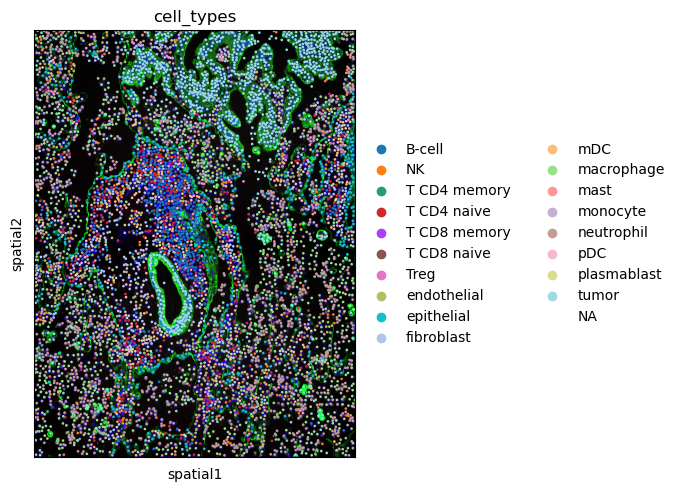

In [16]:
sq.pl.spatial_scatter(adata, color="cell_types",size=15)

In [17]:
data_path = "./Results/" #### to your path
data_name = 'Lung' #### project name
save_path = "./Results/" #### save path

In [18]:
adata.obs

,CenterPatchX,CenterPatchY,imagerow,imagecol,array_row,array_col,cell_types,Width,Height
cell,,,,,,,,,
4-1,521.0,3629.0,521.0,3629.0,521.0,3629.0,epithelial,82,38
4-2,598.0,3619.0,598.0,3619.0,598.0,3619.0,neutrophil,72,59
4-3,780.0,3621.0,780.0,3621.0,780.0,3621.0,epithelial,81,55
4-4,1220.0,3631.0,1220.0,3631.0,1220.0,3631.0,macrophage,76,34
4-5,1426.0,3602.0,1426.0,3602.0,1426.0,3602.0,T CD4 naive,75,92
...,...,...,...,...,...,...,...,...,...
9-3300,2034.0,3670.0,2034.0,3670.0,2034.0,3670.0,fibroblast,44,41
9-3301,530.0,3663.0,530.0,3663.0,530.0,3663.0,epithelial,56,27
9-3302,2422.0,3657.0,2422.0,3657.0,2422.0,3657.0,NaN,41,15


In [19]:
adata=preprocessing(adata)

In [20]:
adata

AnnData object with n_obs × n_vars = 6921 × 960
    obs: 'CenterPatchX', 'CenterPatchY', 'imagerow', 'imagecol', 'array_row', 'array_col', 'cell_types', 'Width', 'Height', 'leiden'
    uns: 'spatial', 'cell_types_colors', 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [21]:
data_name = 'Lung5' #### project name
save_path = "./images-test/" #### save path
save_path_image_crop = Path(os.path.join(save_path, 'Image_crop', f'{data_name}'))
save_path_image_crop
save_path_image_crop.mkdir(parents=True, exist_ok=True)

In [22]:
adata = image_crop(adata, save_path=save_path_image_crop,library_id='Lung-small')

Tiling image: 100%|███████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]


In [24]:
adata = image_feature(adata,50).extract_image_feat()

Extract image feature: 100%|██████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]


In [25]:
adata.write('Lung-small.h5ad')

# Part 2

In [3]:
adata=sc.read_h5ad('Lung-small.h5ad')

In [4]:
TGME = run(use_gpu=True)

In [5]:
adata=adata[adata.obs.cell_types.isin(['Treg','T CD8 memory'])==False]

In [6]:
adata=celltypes_encoding(adata,'cell_types')

Trying to set attribute `.obs` of view, copying.


In [7]:
ct=adata.obs.cell_types.unique()

In [8]:
#adata.obs['array_row']=adata.obs.CenterPatchX
#adata.obs['array_col']=adata.obs.CenterPatchY

In [9]:
adata = TGME._get_augment(ct,adata, adjacent_weight = 0.8, neighbour_k = 12)

Physical distance calculting Done!
The number of nearest tile neighbors in physical distance is: 183.98250686713894
Gene correlation calculting Done!
Cell type composition correlation calculting Done!
Morphological similarity calculting Done!
The weight result of image feature is added to adata.obsm['weights_matrix_all'] !


Find adjacent spots of each spot: 100%|███████████████████████████████████████████████████████████ [ time left: 00:00 ]

(6917, 960) Augmenting...
Step 1: Augment gene representation is Done!


In [10]:
graph_dict = TGME._get_graph(adata.obsm["spatial"], distType="BallTree", k=12)

Step 2: Graph computing is Done!


In [11]:
# Compress the data before pickling
with gzip.open("graph-lung-small.pkl.gz", "wb") as compressed_file:
    pickle.dump(graph_dict, compressed_file)

# Part 3

In [12]:
label_encoder = LabelEncoder()
y_label= label_encoder.fit_transform(adata.obs['cell_types'])
y_label

array([ 7, 13,  7, ...,  5, 16,  5])

In [13]:
x=dim_red_augmented(adata,50)

Computing dimensionality reduction of augmented data...
Done!


In [28]:
from TGME import splitdata
from TGME import CreateDataLoaders
from TGME import GraphLoader
from TGME import TGME
from TGME import train_TGME
from TGME import AllDataLoader
from TGME import extract_embeddings
from TGME import TGME_clustering

In [15]:
X_train, y_train, X_val, y_val, X_test, y_test,train_graph,val_graph,test_graph=splitdata(19,0.1,0.1,x,y_label,graph_dict)

In [16]:
train_loader,val_loader,test_loader=CreateDataLoaders(X_train, y_train, X_val, y_val, X_test, y_test,128)

In [17]:
dataloader_trainG=GraphLoader(train_graph, 128)
dataloader_testG=GraphLoader(test_graph, 128)
dataloader_valG=GraphLoader(val_graph, 128)

In [18]:
batch_size = 128
n_head = 3
n_gene = 50
num_classes=16
d_ff = 1024
dropout_rate = 0.7
mode = 0
input_dim=50
conv_hidden=[32,16]
p_drop=0.1
dec_cluster_n=num_classes
activate="relu"

In [19]:
# Create your TG-ME 
model = TGME(batch_size, n_head, n_gene,num_classes, d_ff, dropout_rate, mode, input_dim, conv_hidden, p_drop,
                dec_cluster_n,activate)

In [20]:
num_epochs = 500
verbose=True
verbose_interval=10
lr=0.001
weight_decay=0.7

In [21]:
model=train_TGME(model,lr, weight_decay,5,verbose,verbose_interval,train_loader,val_loader,dataloader_trainG,dataloader_valG,'./')

Training the model...


Validation:   0%|                                                                                | 0/2 [00:02<?, ?it/s]

Train Loss: 5.6756, Accuracy: 16.03%
Validation Loss: 3.4674, Accuracy: 20.12%
Done!
Total training time: 2.36 seconds
Saving model...
Done!


In [22]:
dataloader_G=GraphLoader(graph_dict, 128)

In [23]:
X=np.array(x)

In [24]:
X_dataloader=AllDataLoader(X, y_label, 128)

In [25]:
model.load_state_dict(torch.load('./TGME-model.pt'))

<All keys matched successfully>

In [26]:
pretrained_model=model

In [27]:
embeddings=extract_embeddings(pretrained_model,X_dataloader, dataloader_G)

Calculating Accuracy: 100%|███████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 100.53it/s]


In [32]:
adata=TGME_clustering(embeddings,adata, 55,1)

Computing clustering...
Evaluating clustering...
Refining clustering...
Done


... storing 'TG-ME_refine_domain' as categorical


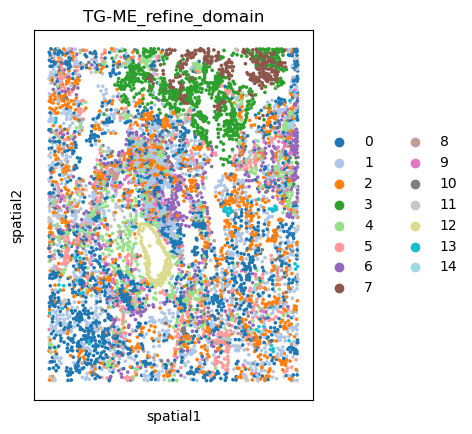

In [33]:
sc.pl.spatial(adata, color=['TG-ME_refine_domain'], spot_size=80,img_key=None,palette='tab20')